<a href="https://colab.research.google.com/github/RiyaThakur14/DATA_SCIENCE/blob/main/bootcamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving ecommerce.csv to ecommerce.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
df=pd.read_csv("ecommerce.csv")
df.head()

,Order_ID,Order_Date,City,Sales_Channel,Customer_Segment,Product_Category,Ad_Spend,Website_Visits,Units_Sold,Unit_Price,Discount_Percent,Delivery_Days,Customer_Rating,Returned,Revenue,Profit
0,ORD0001,2026-04-13,Pune,Website,Returning,Beauty,641.04,98,2,751.47,NaN,5,4.1,Yes,1361.98,349.23
1,ORD0002,2026-01-21,Kolkata,Mobile App,New,Electronics,408.01,129,1,5048.65,13.02,5,4.0,No,4391.46,568.79
2,ORD0003,2026-02-20,Kolkata,Mobile App,New,Grocery,324.73,155,1,412.87,15.60,6,4.1,No,348.48,-141.51
3,ORD0004,2026-03-22,Mumbai,Mobile App,New,Home Decor,204.18,74,6,2130.59,10.98,5,3.7,No,11379.38,3262.91
4,ORD0005,2026-05-04,Mumbai,Website,New,Electronics,373.32,148,1,5961.40,3.17,4,4.9,No,5772.66,1315.58


In [ ]:
## find the most profitable customer segment and product category combination
## find the top 5 segment-category combinations by profit
segment_category_profit=df.groupby(["Customer_Segment","Product_Category"]).agg(Total_profit=("Profit","sum"))
top_5=segment_category_profit.sort_values("Total_profit", ascending=False).head()
print(top_5)

                                   Total_profit
Customer_Segment Product_Category              
New              Electronics           83106.59
Returning        Electronics           59753.29
New              Home Decor            32665.17
                 Fashion               22376.03
Returning        Home Decor            20326.58


In [ ]:
## compare profit between premium and new customers
premium=df[df["Customer_Segment"]=="Premium"]["Profit"]
new=df[df["Customer_Segment"]=="New"]["Profit"]
t_stat,p_value=stats.ttest_ind(premium,new,equal_var=False)
print("premium avg profit",premium.mean())
print("new avg profit",new.mean())
print("p-value",p_value)

premium avg profit 1283.6562962962967
new avg profit 1651.016862745098
p-value 0.22702508200168237


F-statistic 52.62541948979907
p-value 1.9302927669746692e-35


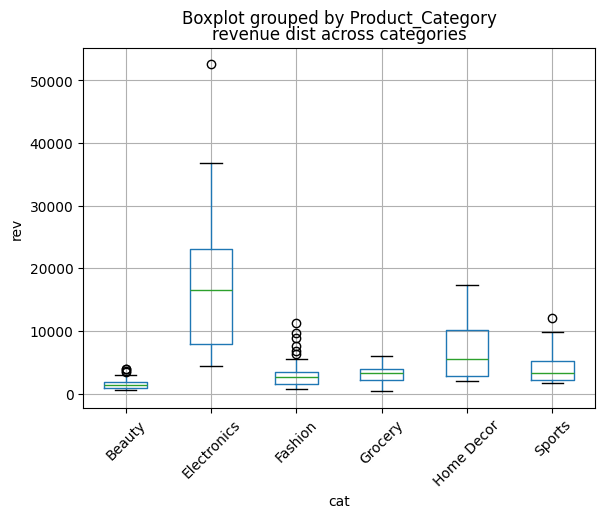

In [ ]:
## ANOVA
## compare reveue across product categories
groups=[]
for category in df["Product_Category"].unique():
  groups.append(df[df["Product_Category"]==category]["Revenue"])
f_stat,p_value=stats.f_oneway(*groups)
print("F-statistic",f_stat)
print("p-value",p_value)
df.boxplot(column="Revenue",by="Product_Category",rot=45)
plt.title("revenue dist across categories")
plt.xlabel("cat")
plt.ylabel("rev")
plt.show()

Returned       No  Yes
Sales_Channel         
Marketplace    44    2
Mobile App     76    4
Social Media   26    1
Website        60    7
chi-square 2.759467118633717
p-value 0.4302158875339791


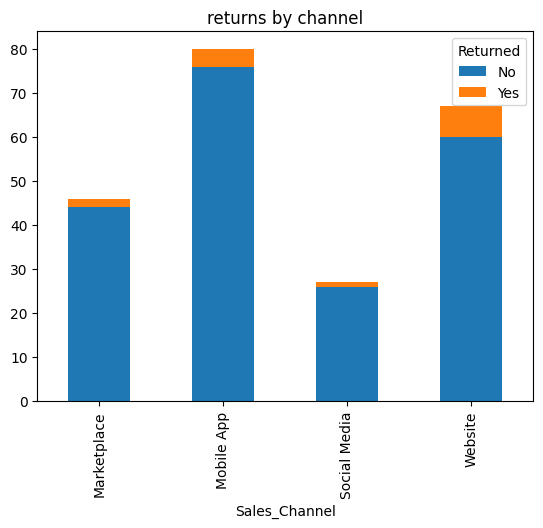

In [ ]:
## check dependency between sales channel and returns
table=pd.crosstab(df["Sales_Channel"],df["Returned"])
chi2,p_value,dof,expected=stats.chi2_contingency(table)
print(table)
print("chi-square",chi2)
print("p-value",p_value)
table.plot(kind="bar",stacked=True)
plt.title("returns by channel")
plt.show()

In [ ]:
## calculate the business probability to find:
## 1. prob that an order is returned
## 2. prob that an order is slow and returned
## 3. prob that an order is returned but delivery is slow

total_orders=len(df)

prob_returned=len(df[df["Returned"]=="Yes"])/total_orders
prob_slow_and_returned=len(df[(df["Delivery_Days"]>5) & (df["Returned"]=="Yes")])/total_orders

slow_orders=df[df["Delivery_Days"]>5]

prob_returned_given_slow=len(slow_orders[slow_orders["Returned"]=="Yes"])/len(slow_orders)

print("P(Returned):",prob_returned)
print("P(Slow and returned):",prob_slow_and_returned)
print("P(Returned | slow)",prob_returned_given_slow)


P(Returned): 0.06363636363636363
P(Slow and returned): 0.022727272727272728
P(Returned | slow) 0.08928571428571429
